# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [46]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [47]:
#load data
nba_stats = pd.read_csv("nba_2025.txt", sep=",", encoding="latin-1")
salaries = pd.read_csv("2025_salaries.csv", header=1, encoding="latin-1") #seperator not needed cause this txt sperated by commas
nba_stats.head()
salaries.head()

,Player,Tm,2025-26
0,Jaden Springer,NOP,"$70,732"
1,Garrison Mathews,IND,"$131,970"
2,Garrison Mathews,IND,"$131,970"
3,Mac McClung,IND,"$164,060"
4,Didi Louzada,POR,"$268,032"


In [48]:
# merge the 2 dataframes in a database style join bases on shared feature "Player"
# help(pd.merge) documenation on merge
merged_data = pd.merge(nba_stats, salaries, on="Player")
#print(nba.columns)
#print(salaries.columns)

In [49]:
#Drop variables that will not be needed or are duplicates
# we drop all duplicates in the merged data's "Player" column
duplicates = merged_data[merged_data.duplicated(subset="Player", keep=False)]
duplicates = duplicates.drop_duplicates(subset = "Player")
# one pair of brackets means not necessarily indexing but trying to subset existing datasets
# two brackets aids with slicing to get specific column or rows
print(duplicates)
#Data wrongler shows that our data contains 166 rows and 56 unique values
#  now subtrat u get 110 whcih u add original (471) get close to 524


#drop uneeded varaibles were determining player performance we are dropping these because features such as row number, age and attempts and percentages fail to contribute compared to performance stats such as team, positon, assists, rebounds, game palyed,etc. So we are gonna be keeping attributes tahta help us identifyly palyers and performance stats as wella s salary which is our main focus 
merged_data = merged_data.drop(['Rk', 'Age', 'FGA', '3PA', '2PA', 'FTA', 'FG%', '3P%', '2P%', 'eFG%', 'FT%', 'ORB', 'DRB', 'Player-additional', 'Tm', 'GS'], axis=1)

        Rk                  Player   Age Team Pos     G    GS      MP     FG  \
11    13.0            James Harden  36.0  2TM  PG  47.0  47.0  1656.0  338.0   
36    37.0             CJ McCollum  34.0  2TM  SG  51.0  37.0  1537.0  354.0   
39    39.0       Jaren Jackson Jr.  26.0  2TM   C  48.0  48.0  1454.0  342.0   
71    70.0         Anfernee Simons  26.0  2TM  SG  53.0   4.0  1328.0  276.0   
85    82.0             Ayo Dosunmu  26.0  2TM  SG  48.0  10.0  1271.0  268.0   
102   97.0           Collin Sexton  27.0  2TM  SG  45.0  13.0  1030.0  221.0   
112  105.0         Duncan Robinson  31.0  DET  SF  51.0  51.0  1437.0  211.0   
115  107.0         De'Andre Hunter  28.0  2TM  SF  45.0  25.0  1176.0  208.0   
121  111.0           Deandre Ayton  27.0  LAL   C  46.0  46.0  1299.0  278.0   
144  133.0            Jock Landale  30.0  2TM   C  49.0  26.0  1146.0  220.0   
158  143.0      Bennedict Mathurin  23.0  2TM  SF  30.0  24.0   948.0  162.0   
167  152.0           Kevin Huerter  27.0

In [50]:
#Run the clustering algo with your best guess for K

# first we gitta make sure all our data is numeric for clustring so featurs liek plaueer id, team, posiiton has to go
print(merged_data) 
#merged_data = merged_data.drop(["Player", "Team", "Pos", "Awards", "2025-26"], axis=1)
nba_cluster_data = merged_data.drop(["Player", "Team", "Pos", "Awards", "2025-26"], axis=1)

# Standard scalr is a scaling method that allows us to put all features on the sam scale by making them z scores with the emna =0 and std =1
merged_data_scaled = StandardScaler().fit_transform(nba_cluster_data)

# we now have all performance stats which we analyze through the clustering algo and our best guess for k
nba_model = KMeans(n_clusters=4, random_state = 42)
nba_model.fit(merged_data_scaled)
# now we gotta assign labels that tell us which cluster each data point was assigned to if we just print it this info isnt stored thouhg so we add a column in our dataframe aligning palyer with cluater label
merged_data["cluster_label"] = nba_model.labels_

                      Player Team Pos     G      MP     FG     3P     2P  \
0    Shai Gilgeous-Alexander  OKC  PG  49.0  1632.0  534.0   87.0  447.0   
1               Tyrese Maxey  PHI  PG  52.0  2008.0  524.0  174.0  350.0   
2           Donovan Mitchell  CLE  SG  51.0  1719.0  516.0  185.0  331.0   
3               Jaylen Brown  BOS  SF  49.0  1676.0  534.0  102.0  432.0   
4              Jalen Brunson  NYK  PG  50.0  1728.0  481.0  146.0  335.0   
..                       ...  ...  ..   ...     ...    ...    ...    ...   
519              Isaac Jones  SAC  PF   3.0    17.0    1.0    0.0    1.0   
520              Isaac Jones  DET  PF   1.0     1.0    1.0    0.0    1.0   
521           Garrett Temple  TOR  SG  13.0    36.0    1.0    1.0    0.0   
522             N'Faly Dante  ATL   C   4.0    15.0    1.0    0.0    1.0   
523             Noa Essengue  CHI  PF   2.0     6.0    0.0    0.0    0.0   

        FT    TRB    AST    STL   BLK    TOV     PF     PTS  Trp-Dbl  Awards  \
0    40

In [51]:
#View the results
#we can see that position, team, etc. have been dropped
print(merged_data)
print(nba_model)

                      Player Team Pos     G      MP     FG     3P     2P  \
0    Shai Gilgeous-Alexander  OKC  PG  49.0  1632.0  534.0   87.0  447.0   
1               Tyrese Maxey  PHI  PG  52.0  2008.0  524.0  174.0  350.0   
2           Donovan Mitchell  CLE  SG  51.0  1719.0  516.0  185.0  331.0   
3               Jaylen Brown  BOS  SF  49.0  1676.0  534.0  102.0  432.0   
4              Jalen Brunson  NYK  PG  50.0  1728.0  481.0  146.0  335.0   
..                       ...  ...  ..   ...     ...    ...    ...    ...   
519              Isaac Jones  SAC  PF   3.0    17.0    1.0    0.0    1.0   
520              Isaac Jones  DET  PF   1.0     1.0    1.0    0.0    1.0   
521           Garrett Temple  TOR  SG  13.0    36.0    1.0    1.0    0.0   
522             N'Faly Dante  ATL   C   4.0    15.0    1.0    0.0    1.0   
523             Noa Essengue  CHI  PF   2.0     6.0    0.0    0.0    0.0   

        FT    TRB    AST    STL   BLK    TOV     PF     PTS  Trp-Dbl  Awards  \
0    40

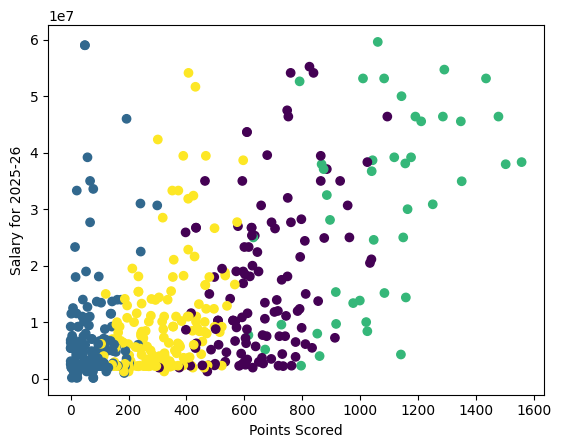

In [53]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters
merged_data["2025-26"] = merged_data["2025-26"].str.replace("$", "").str.replace(",", "").astype(float)
plt.scatter(x = merged_data["PTS"], y = merged_data["2025-26"], c = merged_data["cluster_label"])
plt.xlabel("Points Scored")
plt.ylabel("Salary for 2025-26")
plt.show()

In [54]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
print(nba_model.inertia_)
print(nba_model.labels_)

# silhouette_score
print(silhouette_score(merged_data_scaled, nba_model.labels_))


#Okay, so from what I understand, the total variance is also known as inertia, and this basically
#  measures how close points are to their centroid and how packed they are within this cluster. 
# The silhouette score does the same thing as well, but it also measures how separated clusters are from each other,
# like so the distance between clusters and the distance within clusters. So silhouette score could contribute to the intra and
#  the inter distance.

2391.2157245384137
[2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 0 2 2 2 2 2 2 0 0 0 2 2 2 2 2 0 0
 0 1 0 0 1 2 2 0 2 0 2 0 2 2 0 2 0 2 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 1 0 0 0 2 0 0
 0 0 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 3 0 0 0 0 3 0 0 0 0
 1 1 0 3 0 0 3 3 0 3 3 3 1 3 0 0 0 3 0 0 3 1 3 0 0 0 3 3 1 0 3 3 3 3 3 0 3
 3 3 0 3 3 3 3 3 3 0 0 0 3 0 3 3 0 3 3 1 3 3 3 3 3 1 0 0 3 3 3 3 3 3 3 3 1
 0 0 3 3 3 3 3 3 0 3 3 1 3 3 3 3 1 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 1 1 3 3 3
 3 1 3 3 3 3 3 3 3 1 3 3 3 3 0 3 3 3 3 3 1 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 1 3 3 3 3 3 3 3 1 3 3 3 1 1 3 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 1 3 3 3 3 3 1 1 3 3 3 3 3 1 1 3 3 1 3 1 3 3 1 3 3 3 1 3 3 3 1 1 3 1 3 3 3
 1 3 1 1 3 1 1 3 1 1 3 3 1 3 1 1 1 1 3 1 1 1 1 1 1 3 1 1 1 1 1 1 1 3 1 1 1
 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1

In [55]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient
k_inertia_values = []
k_range = range(2,10)
for x in k_range:
    elbow_model = KMeans(n_clusters=x, random_state = 42)
    elbow_model.fit(merged_data_scaled)
    k_inertia_values.append(elbow_model.inertia_)
# Okay, Mr. Rooney, so at this point, we are gonna run, we are gonna make a list, which is gonna contain all our inertia values, allowing us to see how the elbow plot changes and when it starts to flatten out. Period. If we did not use a list to contain our inertia values, we are essentially gonna be printing out only one inertia value at a time, and we will not be able to see the change as the plot flattens out, which is why we are using a list. Our for loop is gonna run each va;ues of a range of k values that we think might be a good range for us. So these k values are our clusters. So we are gonna be dealing with  9 k values in the range of 2 to 10.

#silhouette coefficient
silhouette_coefficient = []

k_range = range(2,10)
for x in k_range:
    elbow_model = KMeans(n_clusters=x, random_state = 42)
    elbow_model.fit(merged_data_scaled)
    silhouette_coefficient.append(silhouette_score(merged_data_scaled, elbow_model.labels_))

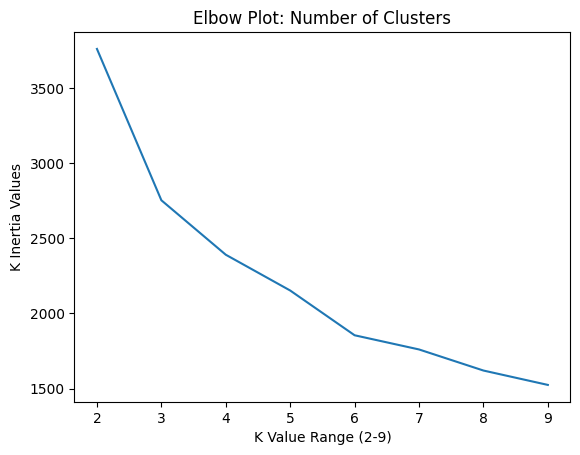

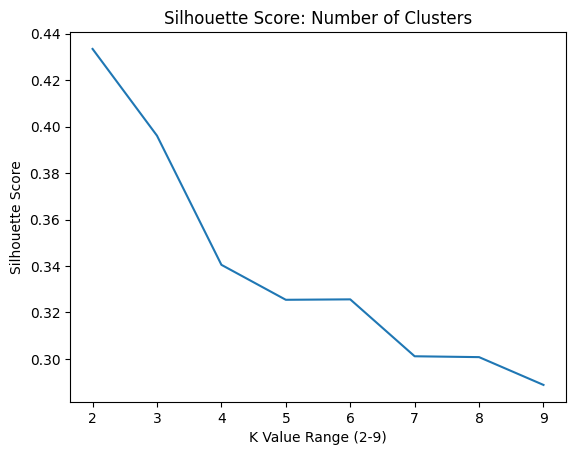

In [56]:
#Visualize the results of the elbow method
#elbow plot
plt.plot(k_range, k_inertia_values)
plt.title("Elbow Plot: Number of Clusters")
plt.xlabel("K Value Range (2-9)")
plt.ylabel("K Inertia Values")
plt.show()

# silhpouette score plot
plt.plot(k_range, silhouette_coefficient)
plt.title("Silhouette Score: Number of Clusters")
plt.xlabel("K Value Range (2-9)")
plt.ylabel("Silhouette Score")
plt.show()

In [57]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
nba_model = KMeans(n_clusters=3, random_state=42)
nba_model.fit(merged_data_scaled)
merged_data["cluster_label"] = nba_model.labels_

In [58]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

#elbow method with k value = 3
elbow_model = KMeans(n_clusters=3, random_state = 42)
elbow_model.fit(merged_data_scaled)

# silhpuette scores
#silhouette_coefficient = KMeans(n_clusters= 3, random_state= 42)
silhouette_coefficient = silhouette_score(merged_data_scaled, nba_model.labels_)

print(nba_model.inertia_)
print(silhouette_coefficient)


2754.0087149035808
0.3961069919811848


In [ ]:
#Use the model to select players for Mr. Rooney to consider

print(merged_data.groupby("cluster_label")[["PTS", "AST", "TRB", "2025-26"]].mean())

# players that are not good choices - they deliver low performance while aquiring a high salary
players_not_good = merged_data[(merged_data["cluster_label"] == 1) & (merged_data["2025-26"] > merged_data["2025-26"].median())]

# players that are good choices - they perform farely well but somewhat undervalued so a slary boost cold be very convincing to them  
players_good_choices = merged_data[(merged_data["cluster_label"] == 0) & (merged_data["2025-26"] < merged_data["2025-26"].median())]

# players that could work - thiugh they are high performers they are more expensive than others
players_could_work = merged_data[merged_data["cluster_label"] == 2]

print(players_not_good[["Player", "PTS", "2025-26"]].head(4))
print(players_good_choices[["Player", "PTS", "2025-26"]].head(4))
print(players_could_work[["Player", "PTS", "2025-26"]].head(3))


                      PTS         AST         TRB       2025-26
cluster_label                                                  
0              434.471154   95.394231  177.278846  1.172091e+07
1               95.352174   21.800000   43.260870  6.835576e+06
2              932.988372  214.662791  284.290698  2.570051e+07
               Player    PTS     2025-26
13       James Harden   58.0  39182693.0
38        CJ McCollum  299.0  30666666.0
41  Jaren Jackson Jr.   67.0  35000000.0
73    Anfernee Simons   67.0  27678571.0
              Player    PTS    2025-26
59        Saddiq Bey  811.0  6118644.0
70  Tim Hardaway Jr.  763.0  2296274.0
93      Jaylon Tyson  693.0  3492480.0
98  Brice Sensabaugh  665.0  2693760.0
                    Player     PTS     2025-26
0  Shai Gilgeous-Alexander  1558.0  38333050.0
1             Tyrese Maxey  1503.0  37958760.0
2         Donovan Mitchell  1478.0  46394100.0
3             Jaylen Brown  1435.0  53142264.0


In [ ]:
#Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.